# __Wearable dataset overview, EDA and preprocessing__

Ilina Durakovska

__Dataset:__ Wearable Device Dataset from Induced Stress and Structured Exercise Sessions \
__Physionet Link:__ [https://physionet.org/content/wearable-device-dataset/1.0.1/](https://physionet.org/content/wearable-device-dataset/1.0.1/) \
__Kaggle (unofficial) Link:__ [https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise](https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise)

In [4]:
import re
import shutil
import tempfile
import warnings
import numpy as np
import pandas as pd
import heartpy as hp
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.signal import butter, filtfilt

In [5]:
warnings.filterwarnings("ignore")

---

# __Overview:__

This data was collected using the Empatica E4, a research-grade wearable wristband that continuously records physiological signals via senzors on the wrist. Blood volume pulse, motion-based activity, skin temperature, and electrodermal activity were colected with the help of healthy volunties that underwent stress sessions, aerobic and anaerobic excersize. <br><br>

## _Participant cohorts:_

The data is composed of two cohorts or sub-gruops that differ in their naming convention and version of the protocol they followed:

| Cohort | IDs | Sex | Protocol |
|--------|-----|-----|----------|
| First stage | S01 - S18     | Male | V1 |
| Second stage | f01 - f18      | Mostly female (one exception) | V2 |

\* There will be a detailed explanation in the difference of the protocols below.

<br>

## _Experimental states:_

__- AEROBIC:__ Moderate-intensity continuous exercise (e.g. cycling or running at a steady pace). Heart rate is elevated but sustainable. \
__- ANAEROBIC:__ High-intensity interval exercise pushing beyond the aerobic threshold. Heart rate reaches near-maximal levels. \
__- STRESS:__ A seated psychological stress protocol involving cognitive tasks designed to induce mental stress without physical exertion. 

<br>

## _Protocols:_

### <u>Stress Incuction Protocol:</u>

__First version (S01 to S18)__

![sip1](pictures/sip1.png)

__Second version (f01 to f18)__

![sip2](pictures/sip2.png)

### <u>Aerobic Protocol:</u>

__First version (S01 to S18)__

![ap1](pictures/ap1.png)

__Second version (f01 to f18)__

![ap2](pictures/ap2.png)

### <u>Anaerobic Protocol:</u>

__First version (S01 to S18)__

![anp1](pictures/anp1.png)

__Second version (f01 to f18)__

![anp2](pictures/anp2.png)

<br>

## _Signal Descriptions:_

The general structure of the different signals thoughout the patient files is as follows:
- Row 0: Contains the session start time (UTC)
- Row 1: Contains the sampling frequency in Hz
- Row 2 and onwards: Contain the signal values

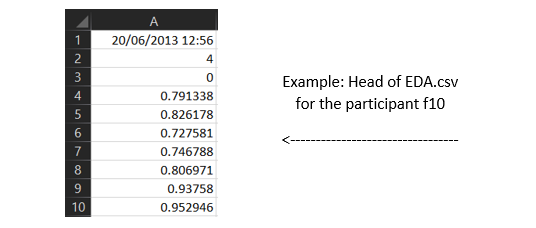

### __BVP - Blood Volume Pulse__

The raw output of the __photoplethysmograph (PPG)__ sensor. A PPG works by shining an LED into the skin and measuring how much light is absorbed - blood absorbs more light than surrounding tissue, so each heartbeat creates a pulse in the signal.

Measured at __64 Hz__

### __HR - Heart Rate__ 

The **average heart rate in beats-per-minute (BPM)**, pre-computed by the E4 firmware from the BVP signal. Updated once per second. Useful as a quick overview but less rich than computing HRV from BVP directly.

Measured at __1 Hz__

### __IBI - Inter-Beat Interval__ 

The time in **seconds between consecutive heartbeats**, also extracted by the E4 from BVP. Unlike the other files, IBI is not sampled at a fixed rate - one row is written for each detected beat.

File structure:
- Column 0: Time offset from session start (seconds)
- Column 1: Duration of that beat interval (seconds)

A healthy resting IBI is roughly 0.6–1.0 s (60–100 BPM). During stress, IBI tends to become shorter and *less variable* - this loss of variability is one of the key biomarkers for stress detection.

Measured at __/__

### __EDA - Electrodermal Activity__

Also called **galvanic skin response (GSR)**. Measures the electrical conductance of the skin in **microsiemens (µS)**. Sweat glands are controlled by the sympathetic nervous system, so EDA rises during stress, excitement, or intense exercise. It does not return to baseline instantly - responses are slow (seconds to minutes).

Measured at __4 Hz__

### __TEMP - Skin Temperature__

Skin surface temperature in **Celsius**. During physical exercise it generally rises due to increased blood flow. During acute stress it can *drop* transiently (vasoconstriction). Useful as a complementary signal but has high inter-individual variability.

Measured at __4 Hz__

### __ACC - 3-axis Accelerometer__

Records wrist acceleration in **x, y, z** axes in units of 1/64g. Useful for:
- Detecting and removing **motion artifacts** from BVP/EDA (movement contaminates these signals)
- Quantifying physical activity intensity as a feature

Measured at __32 Hz__

### __tags - Event Markers__

Timestamps (UTC) of when the researcher pressed the physical button on the E4. These mark **phase transitions** in the protocol - e.g. the start/end of a stress task or an exercise block. The number of tags differs between V1 and V2 protocols as seen before.

<br>

## _Stress Scores:_

`Stress_Level_v1.csv` and `Stress_Level_v2.csv` contain self-reported stress scores collected via questionnaire at multiple points during the stress protocol. These are not signal data, they are subjective ratings (0-10) per task phase.

\* Note: These files are only available for the STRESS sessions, there are no ratings for the aerobic/anaerobic sessions.

<br>

## _Data constraints:_

The existing documentation for this dataset lists several known issues with the data collected from specific participants. I will go over all constraints below, and how they will need to be handled in the preprocessing pipeline.

### __S02 (STRESS) - Duplicated signal data__

The files downloaded from E4 Connect contain duplictated raw values starting at specific rows:

| Signal | Duplication starts at row |
|--------|--------------------------|
| ACC    | 49,545                   |
| BVP    | 99,091                   |
| EDA    | 6,195                    |
| TEMP   | 6,195                    |

__Handling:__ Each signal is truncated at its duplication row before windowing. This also means the usable session is shorter than the others (~25 min of EDA and TEMP instead of the usual ~45 min), but otherwise the data is usable.<br>

### __f07 (STRESS) - Incorrect wristband placement__

The protection dock was never removed from the E4 before the session began, physically blocking the PPG and temperature sensors. As a result of this:
- BVP is invalid (no light could reach the skin)
- TEMP is invalid (sensor was covered)
- EDA is valid (uses a different electrode pad on the underside)
- ACC is valid (accelometer is unnafected the dock)

__Handling:__ HeartPy cannot run on this subjects data since the BVP is unusable, so the data from this person (from the STRESS cohort) will be ommited.<br>

### __f14 (STRESS), S11 (AEROBIC), S16 (ANAEROBIC) - Bluetooth connection loss__

For the mentioned participants and protocols, the bluetooth connection dropped mid-session resulting in a split session. Data for these cases is stored in subfolders.

__Handling:__ The data from these folders will be joined into one, with null values in-place of the missing ones.<br>

### __S03 and S07 (AEROBIC), S06 (ANAEROBIC) - Incomplete protocol__

Participants ended their session early, thus not reaching expected maximum HR.

__Handling:__ No handling is needed, the data is still usable.<br>

### __S01 (ANAEROBIC) - Empty IBI file__

The IBI file for this scenario is empty.

__Handling:__ In the pipeline below, all HRV metrics will bi derived from the BVP via HeartPy, so no handling is needed.<br>

### __S12 (AEROBIC) - No data__

S12 did not preform the aerobic protocol.

__Handling:__ This scenario will be ommited from the data, no special handling needed.<br>

---

# __EDA and preprocessing:__

The **end goal** is to be able to train a model **to predict when a person is entering a stress state in real time**, with little lag. For this purpose, we need to format the data we have accordingly. 

<u>The strategy I'll be going with is the following:</u>

Split the readings into smaller windows that will be used to predict the state the subject is currently in. We can use about 60 seconds of logged data for this, then every 5 seconds slide the window over and predict again. This should provide accurate real time data needed to predict the state of the subject. 

In [90]:
DATASET_PATH = "wearable-device-dataset/Wearable_Dataset/"
STATES = ["AEROBIC", "ANAEROBIC", "STRESS"]

As seen before, the different signals are not measured at the same frequency, eg. BVP is measured at 64 Hz, while EDA is measured at 4 Hz. This tells us there will be a different number of samples for each signal in a given window. For example, in a 5 second window we'll have:
- BVP  64 Hz  ->  320 samples / window
- ACC  32 Hz  ->  160 samples / window
- EDA   4 Hz  ->   20 samples / window
- TEMP  4 Hz  ->   20 samples / window
- HR    1 Hz  ->    5 samples / window
- IBI   irregular ->  ~ 4-7 values / window (one per heartbeat)

In [92]:
SIGNAL_HZ = {
    "BVP" : 64,
    "ACC" : 32,
    "EDA" : 4,
    "TEMP": 4,
    "HR"  : 1,
}

### _Helpers for handling the duplicated and invalid data:_

In [94]:
TRUNCATE_AT = {
    ("S02", "STRESS"): {
        "BVP" : 99091,
        "ACC" : 49545,
        "EDA" : 6195,
        "TEMP": 6195,
    }
}

In [95]:
INVALID_BVP = {("f07", "STRESS")}

## Loading the data:

### _Helper functions:_

In [98]:
def load_signal(filepath, col_names):
    """
    Load a fixed-rate Empatica E4 signal file.

    Returns
    -------
    values : np.ndarray raw signal values
    sample_rate : float
    start_time : pd.Timestamp (UTC)
    """
    raw = pd.read_csv(filepath, header=None)
    start_time = pd.to_datetime(raw.iloc[0, 0])
    sample_rate = float(raw.iloc[1, 0])
    data = raw.iloc[2:].reset_index(drop=True)
    data.columns = col_names
    data = data.apply(pd.to_numeric, errors="coerce")
    return data.values, sample_rate, start_time

In [99]:
def load_ibi(filepath):
    """
    Load IBI (irregular timestamps - one row per detected heartbeat).

    Returns
    -------
    offsets : np.ndarray (seconds from session start for each beat)
    ibi_sec : np.ndarray (duration of that inter-beat interval in seconds)
    """
    header = pd.read_csv(filepath, nrows=0)
    data = pd.read_csv(filepath, header=None, skiprows=1)
    data.columns = ["offset_sec", "ibi_sec"]
    data = data.apply(pd.to_numeric, errors="coerce").dropna()
    return data["offset_sec"].values, data["ibi_sec"].values

In [100]:
def safe_load(session_path, fname, cols):
    path = os.path.join(session_path, fname)
    if os.path.exists(path):
        vals, hz, start = load_signal(path, cols)
        return vals.astype(float), hz, start
    return None, None, None

In [101]:
def samples_in_window(hz, offset_start_sec, window_sec):
    """ How many samples of a signal fall inside a window starting at offset_start_sec. """
    s = int(offset_start_sec * hz)
    e = s + int(window_sec * hz)
    return s, e

In [102]:
def load_tags(session_path, bvp_start):
    """
    Load tags.csv and return each tag's offset in seconds from session start.

    Tags mark protocol phase transitions - each one was produced by the 
    researcher pressing the physical button on the E4 wristband.

    Parameters
    ----------
    session_path : str
    bvp_start : pd.Timestamp (session start time (row 0 of BVP.csv))

    Returns
    -------
    np.ndarray of float  tag offsets in seconds from session start, or empty array if tags.csv is missing
    """
    path = os.path.join(session_path, "tags.csv")
    if not os.path.exists(path):
        return np.array([])

    try:
        tags = pd.read_csv(path, header=None)
    except pd.errors.EmptyDataError:
        return np.array([])

    tags.columns = ["timestamp"]
    tags["timestamp"] = pd.to_datetime(tags["timestamp"])
    offsets = (tags["timestamp"] - bvp_start).dt.total_seconds().values
    return offsets

In [103]:
def assign_phase(t_end_sec, tag_offsets, phases, label_window_sec=10):
    """
    Determine which protocol phase a window belongs to based on its trailing edge.

    Parameters
    ----------
    t_end_sec : float - end of the window in seconds from session start
    tag_offsets : np.ndarray - tag positions in seconds (from load_tags)
    phases : list of (phase_name, state_label) tuples
    label_window_sec : int - how many trailing seconds to use for the vote 

    Returns
    -------
    phase_name : str
    state_label : str
    """
    t_label_start = t_end_sec - label_window_sec

    idx_start = int(np.searchsorted(tag_offsets, t_label_start, side="right"))
    idx_end   = int(np.searchsorted(tag_offsets, t_end_sec,     side="right"))

    idx_start = min(idx_start, len(phases) - 1)
    idx_end   = min(idx_end,   len(phases) - 1)

    if idx_start == idx_end:
        return phases[idx_end]

    boundaries = [t_label_start]
    for tag in tag_offsets:
        if t_label_start < tag < t_end_sec:
            boundaries.append(tag)
    boundaries.append(t_end_sec)

    phase_durations = {}
    n_segments = len(boundaries) - 1
    for seg in range(n_segments):
        phase_idx = min(idx_start + seg, len(phases) - 1)
        duration  = boundaries[seg + 1] - boundaries[seg]
        phase_durations[phase_idx] = phase_durations.get(phase_idx, 0) + duration

    dominant_idx = max(phase_durations, key=phase_durations.get)
    return phases[dominant_idx]

### _Split session helpers:_

The following functions handle Bluetooth dropout sessions (f14, S11, S16) where
the recording split into `_a` and `_b` parts. They merge both parts into a single
in-memory session with NaN-filled gap so the rest of the pipeline sees one continuous recording.


In [105]:
def read_e4_header(csv_path):
    """
    Return (start_timestamp, sample_rate) from an E4 CSV header.
    Handles multi-column signals like ACC where both header rows are comma-separated.

    Parameters
    ----------
    csv_path : str

    Returns
    -------
    start : pd.Timestamp
    rate : float
    """
    with open(csv_path, "r") as fh:
        lines = [fh.readline().strip() for _ in range(2)]
    start = pd.Timestamp(lines[0].split(",")[0])
    rate  = float(lines[1].split(",")[0])
    return start, rate

In [106]:
def load_raw_values(csv_path):
    """
    Return the data rows of an E4 CSV as a numpy array, skipping the 2-row header.

    Parameters
    ----------
    csv_path : str

    Returns
    -------
    np.ndarray, shape (n_samples, n_columns)
    """
    return pd.read_csv(csv_path, header=None, skiprows=2).values

In [107]:
def fill_gap_and_concat(path_a_sig, path_b_sig, out_path):
    """
    Merge two parts of a split session signal into a single CSV.

    The gap between the end of _a and the start of _b is filled with NaN rows
    so that sample indices remain aligned with wall-clock time. This means
    tag offsets computed from the merged file stay valid.

    Parameters
    ----------
    path_a_sig : str - path to the _a signal CSV
    path_b_sig : str - path to the _b signal CSV
    out_path : str - destination path for the merged CSV
    """
    if not os.path.exists(path_a_sig):
        if os.path.exists(path_b_sig):
            shutil.copy(path_b_sig, out_path)
        return

    start_a, rate_a = read_e4_header(path_a_sig)
    data_a = load_raw_values(path_a_sig)
    n_cols = data_a.shape[1] if data_a.ndim > 1 else 1

    if os.path.exists(path_b_sig):
        start_b, _ = read_e4_header(path_b_sig)
        data_b = load_raw_values(path_b_sig)

        end_a = start_a + pd.Timedelta(seconds=len(data_a) / rate_a)
        gap_sec = max((start_b - end_a).total_seconds(), 0)
        gap_samples = int(round(gap_sec * rate_a))

        if gap_samples > 0:
            gap_fill = np.full((gap_samples, n_cols), np.nan)
            merged_data = np.vstack([data_a.reshape(-1, n_cols),
                                     gap_fill,
                                     data_b.reshape(-1, n_cols)])
        else:
            merged_data = np.vstack([data_a.reshape(-1, n_cols),
                                     data_b.reshape(-1, n_cols)])
    else:
        merged_data = data_a.reshape(-1, n_cols)

    with open(path_a_sig, "r") as fh:
        header_lines = [fh.readline() for _ in range(2)]

    with open(out_path, "w", newline="") as fh:
        fh.writelines(header_lines)
        for row in merged_data:
            fh.write(",".join("" if (isinstance(v, float) and np.isnan(v)) else str(v) for v in row ) + "\n")

In [108]:
def merge_tags(path_a_tags, path_b_tags, out_path):
    """
    Concatenate tag timestamps from two split session parts into one file.

    Tags are already in wall-clock order, so simple concatenation is correct.

    Parameters
    ----------
    path_a_tags : str
    path_b_tags : str
    out_path : str
    """
    lines = []
    for p in [path_a_tags, path_b_tags]:
        if os.path.exists(p):
            with open(p, "r") as fh:
                content = fh.read().strip()
                if content:
                    lines.append(content)
    with open(out_path, "w") as fh:
        fh.write("\n".join(lines) + ("\n" if lines else ""))

In [109]:
SIGNALS = ["BVP.csv", "EDA.csv", "TEMP.csv", "ACC.csv", "HR.csv", "IBI.csv"]

In [110]:
def merge_split_sessions(path_a, path_b):
    """
    Merge two split session folders (_a and _b) into a single temporary directory.

    Each signal is gap-filled (NaN) over the Bluetooth dropout interval so that
    sample indices stay aligned with wall-clock time and tag offsets remain valid.
    The temporary directory is written to disk and its path is returned; the caller
    is responsible for deleting it with shutil.rmtree() after use.

    Parameters
    ----------
    path_a : str - folder for the _a (first) part
    path_b : str - folder for the _b (second) part

    Returns
    -------
    str path to the temporary merged directory
    """
    tmp = tempfile.mkdtemp(prefix="merged_session_")

    for sig in SIGNALS:
        fill_gap_and_concat(
            os.path.join(path_a, sig),
            os.path.join(path_b, sig),
            os.path.join(tmp, sig),
        )

    merge_tags(
        os.path.join(path_a, "tags.csv"),
        os.path.join(path_b, "tags.csv"),
        os.path.join(tmp, "tags.csv"),
    )

    return tmp

In [111]:
def get_base_patient_id(folder_name):
    """
    Strip a trailing _a / _b suffix to get the canonical patient ID.

    Parameters
    ----------
    folder_name : str

    Returns
    -------
    str
    """
    return re.sub(r"_[ab]$", "", folder_name)

In [112]:
def group_split_patients(patients):
    """
    Group _a / _b folder pairs by their canonical patient ID.

    Parameters
    ----------
    patients : list of str  — sorted folder names as returned by os.listdir

    Returns
    -------
    list of (canonical_id, [folder_names]) tuples, sorted by canonical_id
    """
    groups = {}
    for p in patients:
        base = get_base_patient_id(p)
        groups.setdefault(base, []).append(p)
    return sorted(groups.items())


### _State label values:_
- `"rest"` -> baseline, cool-down, inter-task rest periods
- `"aerobic"` -> sustained aerobic exercise bolcks
- `"anaerobic"` -> sprint blocks
- `"stress"` -> cognitive stress tasks (TCMT, opinion tasks, subtraction)

### _Protocol phase maps:_


In [115]:
PROTOCOL_PHASES = {
    ("STRESS", "S"): [
        ("baseline",          "rest"),
        ("stroop",            "stress"),
        ("stroop",            "stress"),
        ("first_rest",        "rest"),
        ("first_rest",        "rest"),
        ("tmct",              "stress"),
        ("second_rest",       "rest"),
        ("real_opinion",      "stress"),
        ("real_opinion",      "stress"),
        ("opposite_opinion",  "stress"),
        ("opposite_opinion",  "stress"),
        ("subtract_test",     "stress"),
        ("subtract_test",     "stress"),
        ("end",               "rest"),
    ],

    ("STRESS", "f"): [
        ("baseline",          "rest"),
        ("baseline",          "rest"),
        ("tmct",              "stress"),
        ("first_rest",        "rest"),
        ("real_opinion",      "stress"),
        ("opposite_opinion",  "stress"),
        ("second_rest",       "rest"),
        ("subtract_test",     "stress"),
        ("subtract_test",     "stress"),
        ("end",               "rest"),
    ],

    ("AEROBIC", "S"): [
        ("pre_protocol",  "rest"),
        ("warmup",        "aerobic"),
        ("60rpm",         "aerobic"),
        ("70rpm",         "aerobic"),
        ("75rpm",         "aerobic"),
        ("80rpm",         "aerobic"),
        ("85rpm",         "aerobic"),
        ("90rpm",         "aerobic"),
        ("95rpm",         "aerobic"),
        ("100rpm",        "aerobic"),
        ("105rpm",        "aerobic"),
        ("110rpm",        "aerobic"),
        ("cooldown",      "rest"),
    ],

    ("AEROBIC", "f"): [
        ("pre_protocol",  "rest"),
        ("warmup",        "aerobic"),
        ("70rpm",         "aerobic"),
        ("75rpm",         "aerobic"),
        ("80rpm",         "aerobic"),
        ("85rpm",         "aerobic"),
        ("90_95rpm",      "aerobic"),
        ("cooldown",      "rest"),
        ("rest",          "rest"),
    ],

    ("ANAEROBIC", "S"): [
        ("warmup",       "rest"),
        ("sprint_1",     "anaerobic"),
        ("cooldown_1",   "rest"),
        ("sprint_2",     "anaerobic"),
        ("cooldown_2",   "rest"),
        ("sprint_3",     "anaerobic"),
        ("cooldown_3",   "rest"),
        ("rest",         "rest"),
    ],

    ("ANAEROBIC", "f"): [
        ("pre_protocol",  "rest"),
        ("warmup",        "rest"),
        ("sprint_1",      "anaerobic"),
        ("cooldown_1",    "rest"),
        ("sprint_2",      "anaerobic"),
        ("cooldown_2",    "rest"),
        ("sprint_3",      "anaerobic"),
        ("cooldown_3",    "rest"),
        ("sprint_4",      "anaerobic"),
        ("cooldown_4",    "rest"),
        ("rest",          "rest"),
        ("end",           "rest"),
    ],
}

In [116]:
STATE_LABEL_MAP = {"rest": 0, "aerobic": 1, "anaerobic": 2, "stress": 3}

### _Building the windows:_

In [118]:
def build_windows(patient_id, session_path, label, window_sec=60, overlap=55/60):
    """
    Segment one patient session into overlapping windows and extract features.

    Parameters
    ----------
    patient_id : str (e.g. "f01")
    session_path : str (path to the folder with CSV files)
    label : str ("AEROBIC", "ANAEROBIC", or "STRESS")
    window_sec : int (window size in seconds)
    overlap : float (fractional overlap between windows, 0-<1)

    Returns
    -------
    pd.DataFrame with one row per window
    """
    rows = []

    base_id = patient_id.rstrip("_ab")
    cohort  = "S" if base_id[0].upper() == "S" else "f"
    phases  = PROTOCOL_PHASES.get((label, cohort))

    # ── Load BVP ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    bvp_path = os.path.join(session_path, "BVP.csv")
    if not os.path.exists(bvp_path):
        print(f"  [{patient_id}] BVP.csv missing - skipping")
        return pd.DataFrame()

    bvp_vals, bvp_hz, bvp_start = load_signal(bvp_path, ["bvp"])
    bvp_vals = bvp_vals[:, 0].astype(float)

    trunc = TRUNCATE_AT.get((patient_id, label), {})
    if "BVP" in trunc:
        bvp_vals = bvp_vals[:trunc["BVP"]]

    # Bandpass filter once for the whole session (0.5–8 Hz = heartbeat band)
    bvp_filtered = hp.filter_signal(bvp_vals, cutoff=[0.5, 8], sample_rate=bvp_hz, order=3, filtertype="bandpass")

    # ── Load tags (phase boundaries) ─────────────────────────────────────────────────────────────────────────────────────────────────────────
    tag_offsets = load_tags(session_path, bvp_start)

    expected_n_tags = len(phases) - 1 if phases else None
    if phases is not None and len(tag_offsets) != expected_n_tags:
        print(f"  [{patient_id}/{label}] WARNING: expected {expected_n_tags} tags, "
              f"got {len(tag_offsets)} — phase labels may be misaligned")

    # ── Load supporting signals ───────────────────────────────────────────────────────────────────────────────────────────────────────────────
    eda_vals, eda_hz, _ = safe_load(session_path, "EDA.csv", ["eda"])
    temp_vals, temp_hz, _ = safe_load(session_path, "TEMP.csv", ["temp"])
    acc_vals, acc_hz, _ = safe_load(session_path, "ACC.csv", ["acc_x", "acc_y", "acc_z"])

    if eda_vals is not None and "EDA" in trunc: eda_vals = eda_vals [:trunc["EDA"]]
    if temp_vals is not None and "TEMP" in trunc: temp_vals = temp_vals[:trunc["TEMP"]]
    if acc_vals is not None and "ACC" in trunc: acc_vals = acc_vals [:trunc["ACC"]]

    # ── Pre-compute phasic EDA filter coefficients (0.05 Hz high-pass) ───────────────────────────────────────────────────────────────────────
    # EDA = tonic (slow drift) + phasic (fast skin conductance responses).
    # A simple 2nd-order Butterworth high-pass at 0.05 Hz removes the tonic 
    # baseline, leaving the phasic bursts that are most diagnostic for stress.
    if eda_vals is not None:
        b_hp, a_hp = butter(2, 0.05 / (eda_hz / 2), btype="high")
        eda_flat = eda_vals[:, 0].astype(float)
        eda_phasic_full = filtfilt(b_hp, a_hp, eda_flat)
    else:
        eda_phasic_full = None

    # ── Window parameters ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
    bvp_win  = int(window_sec * bvp_hz)
    bvp_step = int(bvp_win * (1 - overlap))

    # Acceleration magnitude threshold for motion-artifact flagging.
    # 1/64g units; ~0.5g peak-to-peak is a commonly used threshold in the
    # wearable literature for detecting significant wrist movement.
    ACC_MOTION_THRESHOLD_STD = 8

    HP_METRICS = ["bpm", "ibi", "sdnn", "rmssd", "pnn20", "pnn50", "hr_mad", "sd1", "sd2", "sd1/sd2", "breathingrate"]

    n_total = len(bvp_filtered)

    TRAIL_SEC = 10

    for win_idx, bvp_start_sample in enumerate(range(0, n_total - bvp_win + 1, bvp_step)):
        bvp_end_sample = bvp_start_sample + bvp_win
        offset_start = bvp_start_sample / bvp_hz
        offset_end = offset_start + window_sec

        # ── Phase labelling (trailing 10 s of window) ─────────────────────────────────────────────────────────────────────────────────────────
        if phases is not None and len(tag_offsets) > 0:
            phase_name, state_label = assign_phase(offset_end, tag_offsets, phases,
                                                   label_window_sec=10)
        else:
            phase_name  = "unknown"
            state_label = label.lower()

        row = {
            "patient_id"  : patient_id,
            "session" : label,
            "phase" : phase_name,
            "state_label" : state_label,
            "state_label_int": STATE_LABEL_MAP.get(state_label, -1),
            "window_index": win_idx,
            "t_start_sec" : round(offset_start, 3),
            "t_end_sec" : round(offset_end,   3),
        }

        # ── HeartPy on BVP slice ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
        bvp_slice = bvp_filtered[bvp_start_sample:bvp_end_sample]
        try:
            wd, m = hp.process(bvp_slice, sample_rate=bvp_hz, calc_freq=False)
            for metric in HP_METRICS:
                val = m.get(metric, np.nan)
                row[f"hp_{metric}"] = float(val) if not isinstance(val, str) else np.nan
            row["hp_quality_flag"] = 0
        except Exception:
            for metric in HP_METRICS:
                row[f"hp_{metric}"] = np.nan
            row["hp_quality_flag"] = 1

        # ── EDA ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        if eda_vals is not None:
            s, e = samples_in_window(eda_hz, offset_start, window_sec)
            chunk_tonic  = eda_vals[s:e, 0] if e <= len(eda_vals) else eda_vals[s:, 0]
            chunk_phasic = eda_phasic_full[s:e] if e <= len(eda_phasic_full) else eda_phasic_full[s:]
            if len(chunk_tonic) > 0:
                row["eda_mean"] = float(np.nanmean(chunk_tonic))
                row["eda_std"] = float(np.nanstd(chunk_tonic))  if len(chunk_tonic) > 1 else np.nan
                row["eda_phasic_mean"] = float(np.nanmean(chunk_phasic))
                row["eda_phasic_std"] = float(np.nanstd(chunk_phasic)) if len(chunk_phasic) > 1 else np.nan
                row["eda_phasic_max"] = float(np.nanmax(chunk_phasic))
            else:
                row["eda_mean"] = row["eda_std"] = np.nan
                row["eda_phasic_mean"] = row["eda_phasic_std"] = row["eda_phasic_max"] = np.nan
        else:
            row["eda_mean"] = row["eda_std"] = np.nan
            row["eda_phasic_mean"] = row["eda_phasic_std"] = row["eda_phasic_max"] = np.nan

        # ── Trailing-10s EDA ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        trail_start_eda = max(offset_end - TRAIL_SEC, offset_start)
        if eda_vals is not None:
            s_t, e_t = samples_in_window(eda_hz, trail_start_eda, offset_end - trail_start_eda)
            chunk_tonic_t  = eda_vals[s_t:e_t, 0] if e_t <= len(eda_vals) else eda_vals[s_t:, 0]
            chunk_phasic_t = eda_phasic_full[s_t:e_t] if e_t <= len(eda_phasic_full) else eda_phasic_full[s_t:]
            if len(chunk_tonic_t) > 0:
                row["eda_mean_trail"] = float(np.nanmean(chunk_tonic_t))
                row["eda_std_trail"] = float(np.nanstd(chunk_tonic_t))   if len(chunk_tonic_t)  > 1 else np.nan
                row["eda_phasic_mean_trail"] = float(np.nanmean(chunk_phasic_t))
                row["eda_phasic_std_trail"] = float(np.nanstd(chunk_phasic_t))  if len(chunk_phasic_t) > 1 else np.nan
                row["eda_phasic_max_trail"] = float(np.nanmax(chunk_phasic_t))
                if len(chunk_tonic_t) > 1:
                    t_axis = np.arange(len(chunk_tonic_t)) / eda_hz
                    row["eda_slope_trail"] = float(np.polyfit(t_axis, chunk_tonic_t, 1)[0])
                else:
                    row["eda_slope_trail"] = np.nan
            else:
                for k in ["eda_mean_trail", "eda_std_trail", "eda_phasic_mean_trail", "eda_phasic_std_trail", 
                          "eda_phasic_max_trail", "eda_slope_trail"]:
                    row[k] = np.nan
        else:
            for k in ["eda_mean_trail", "eda_std_trail", "eda_phasic_mean_trail", "eda_phasic_std_trail", 
                      "eda_phasic_max_trail", "eda_slope_trail"]:
                row[k] = np.nan

        # ── TEMP ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        if temp_vals is not None:
            s, e = samples_in_window(temp_hz, offset_start, window_sec)
            chunk = temp_vals[s:e, 0] if e <= len(temp_vals) else temp_vals[s:, 0]
            row["temp_mean"] = float(np.nanmean(chunk)) if len(chunk) > 0 else np.nan
        else:
            row["temp_mean"] = np.nan

        # ── Trailing-10s TEMP ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        trail_start_temp = max(offset_end - TRAIL_SEC, offset_start)
        if temp_vals is not None:
            s_t, e_t = samples_in_window(temp_hz, trail_start_temp, offset_end - trail_start_temp)
            chunk_t = temp_vals[s_t:e_t, 0] if e_t <= len(temp_vals) else temp_vals[s_t:, 0]
            if len(chunk_t) > 0:
                row["temp_mean_trail"] = float(np.nanmean(chunk_t))
                if len(chunk_t) > 1:
                    t_axis = np.arange(len(chunk_t)) / temp_hz
                    row["temp_slope_trail"] = float(np.polyfit(t_axis, chunk_t, 1)[0])
                else:
                    row["temp_slope_trail"] = np.nan
            else:
                row["temp_mean_trail"]  = np.nan
                row["temp_slope_trail"] = np.nan
        else:
            row["temp_mean_trail"]  = np.nan
            row["temp_slope_trail"] = np.nan

        # ── ACC ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        if acc_vals is not None:
            s, e = samples_in_window(acc_hz, offset_start, window_sec)
            chunk = acc_vals[s:e] if e <= len(acc_vals) else acc_vals[s:]
            if len(chunk) > 0:
                mag = np.sqrt(chunk[:, 0]**2 + chunk[:, 1]**2 + chunk[:, 2]**2)
                acc_mean = float(np.nanmean(mag))
                acc_std  = float(np.nanstd(mag))
                row["acc_mag_mean"] = acc_mean
                row["acc_mag_std"] = acc_std
                row["motion_artifact_flag"] = int(acc_std > ACC_MOTION_THRESHOLD_STD)
            else:
                row["acc_mag_mean"] = row["acc_mag_std"] = np.nan
                row["motion_artifact_flag"] = 0
        else:
            row["acc_mag_mean"] = row["acc_mag_std"] = np.nan
            row["motion_artifact_flag"] = 0

        # ── Trailing-10s ACC ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        trail_start_acc = max(offset_end - TRAIL_SEC, offset_start)
        if acc_vals is not None:
            s_t, e_t = samples_in_window(acc_hz, trail_start_acc, offset_end - trail_start_acc)
            chunk_t = acc_vals[s_t:e_t] if e_t <= len(acc_vals) else acc_vals[s_t:]
            if len(chunk_t) > 0:
                mag_t = np.sqrt(chunk_t[:, 0]**2 + chunk_t[:, 1]**2 + chunk_t[:, 2]**2)
                row["acc_mag_mean_trail"] = float(np.nanmean(mag_t))
                row["acc_mag_std_trail"]  = float(np.nanstd(mag_t))
            else:
                row["acc_mag_mean_trail"] = np.nan
                row["acc_mag_std_trail"]  = np.nan
        else:
            row["acc_mag_mean_trail"] = np.nan
            row["acc_mag_std_trail"]  = np.nan

        for base, trail in [
            ("eda_mean", "eda_mean_trail"),
            ("eda_phasic_mean", "eda_phasic_mean_trail"),
            ("temp_mean", "temp_mean_trail"),
            ("acc_mag_mean", "acc_mag_mean_trail"),
        ]:
            b_val = row.get(base,  np.nan)
            t_val = row.get(trail, np.nan)
            delta_key = base.replace("_mean", "_delta") if "_mean" in base else f"{base}_delta"
            row[delta_key] = float(t_val - b_val) if (not np.isnan(t_val) and not np.isnan(b_val)) else np.nan

        rows.append(row)

    return pd.DataFrame(rows)


### _Building the dataframe:_

In [120]:
WINDOW_SEC = 60
OVERLAP = 55/60

For each trial, we build their windows and add tem to the dataset:

In [122]:
all_dfs = []

for state in STATES:
    state_path = os.path.join(DATASET_PATH, state)
    if not os.path.isdir(state_path):
        print(f"Skipping {state} — not found at {state_path}")
        continue

    raw_patients = sorted([
        p for p in os.listdir(state_path)
        if os.path.isdir(os.path.join(state_path, p))
    ])
    patient_groups = group_split_patients(raw_patients)
    print(f"\n[{state}] {len(patient_groups)} patient(s): {[pid for pid, _ in patient_groups]}")

    for patient_id, folders in patient_groups:
        tmp_dir = None 

        if (patient_id, state) in INVALID_BVP:
            print(f"  {patient_id}... skipped (invalid sensor placement)")
            continue

        print(f"  {patient_id}...", end=" ", flush=True)

        try:
            if len(folders) == 2:
                folders_sorted = sorted(folders)  # ensures _a before _b
                path_a = os.path.join(state_path, folders_sorted[0])
                path_b = os.path.join(state_path, folders_sorted[1])
                session_path = merge_split_sessions(path_a, path_b)
                tmp_dir = session_path
            else:
                session_path = os.path.join(state_path, folders[0])

            df = build_windows(patient_id, session_path, state,
                               window_sec=WINDOW_SEC, overlap=OVERLAP)
        finally:
            if tmp_dir and os.path.isdir(tmp_dir):
                shutil.rmtree(tmp_dir, ignore_errors=True)

        if len(df) > 0:
            all_dfs.append(df)
            print(f"{len(df)} windows")
        else:
            print("skipped")

dataset = pd.concat(all_dfs, ignore_index=True)

print(f"\nFinished: {len(dataset)} total windows  |  {WINDOW_SEC}s window  |  {int(OVERLAP*60)}s stride")


[AEROBIC] 30 patient(s): ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13']
  S01... 397 windows
  S02... 396 windows
  S03...   [S03/AEROBIC] WARNING: expected 12 tags, got 7 — phase labels may be misaligned
276 windows
  S04... 397 windows
  S05... 384 windows
  S06... 402 windows
  S07...   [S07/AEROBIC] WARNING: expected 12 tags, got 9 — phase labels may be misaligned
324 windows
  S08... 394 windows
  S09... 396 windows
  S10... 396 windows
  S11...   [S11/AEROBIC] WARNING: expected 12 tags, got 11 — phase labels may be misaligned
372 windows
  S13... 406 windows
  S14... 423 windows
  S15... 396 windows
  S16... 397 windows
  S17... 396 windows
  S18... 397 windows
  f01... 528 windows
  f02... 340 windows
  f03... 528 windows
  f04... 492 windows
  f05... 604 windows
  f06... 531 windows
  f07... 455 windows
  f08... 466

In [123]:
print(f"\nState label distribution:")
print(dataset["state_label"].value_counts())
print(f"\nHeartPy quality failures: {dataset['hp_quality_flag'].sum()} / {len(dataset)} "
      f"({100*dataset['hp_quality_flag'].mean():.1f}%)")


State label distribution:
state_label
rest         23241
aerobic       9518
stress        6200
anaerobic      724
Name: count, dtype: int64

HeartPy quality failures: 755 / 39683 (1.9%)


In [124]:
print(f"\nMotion-artifact windows by state:")
ma = dataset.groupby("state_label")["motion_artifact_flag"].agg(
    flagged="sum", total="count"
)
ma["pct"] = (ma["flagged"] / ma["total"] * 100).round(1)
print(ma.to_string())


Motion-artifact windows by state:
             flagged  total  pct
state_label                     
aerobic          590   9518  6.2
anaerobic         70    724  9.7
rest            1871  23241  8.1
stress            21   6200  0.3


### _Checking the data:_

In [126]:
dataset.head(10)

,patient_id,session,phase,state_label,state_label_int,window_index,t_start_sec,t_end_sec,hp_bpm,hp_ibi,...,temp_slope_trail,acc_mag_mean,acc_mag_std,motion_artifact_flag,acc_mag_mean_trail,acc_mag_std_trail,eda_delta,eda_phasic_delta,temp_delta,acc_mag_delta
0,S01,AEROBIC,pre_protocol,rest,0,0,0.0,60.0,99.426172,603.462838,...,-0.001921,63.173748,1.733079,0,63.260204,1.412997,0.006848,-0.006157,-0.035833,0.086456
1,S01,AEROBIC,pre_protocol,rest,0,1,5.0,65.0,99.355904,603.889628,...,-0.002161,63.175358,1.407620,0,63.303123,1.420491,0.006010,0.001123,-0.042667,0.127764
2,S01,AEROBIC,pre_protocol,rest,0,2,10.0,70.0,99.310345,604.166667,...,-0.003002,63.183880,1.417658,0,63.291207,1.417982,0.006117,0.001175,-0.049667,0.107326
3,S01,AEROBIC,pre_protocol,rest,0,3,15.0,75.0,98.942229,606.414474,...,-0.003962,63.190549,1.434628,0,63.209477,1.492531,0.005994,0.000264,-0.053667,0.018928
4,S01,AEROBIC,pre_protocol,rest,0,4,20.0,80.0,98.382706,609.863281,...,-0.003062,63.211475,1.473235,0,63.243209,1.688093,0.005637,-0.000297,-0.059167,0.031734
5,S01,AEROBIC,pre_protocol,rest,0,5,25.0,85.0,97.696840,614.144737,...,-0.002522,63.218793,1.472237,0,63.299271,1.606352,0.006155,0.000035,-0.063333,0.080478
6,S01,AEROBIC,pre_protocol,rest,0,6,30.0,90.0,97.360960,616.263441,...,-0.002882,63.245586,1.470551,0,63.331601,1.441189,0.006427,0.000147,-0.064167,0.086015
7,S01,AEROBIC,pre_protocol,rest,0,7,35.0,95.0,97.006181,618.517287,...,-0.003002,63.241830,1.449537,0,63.255298,1.341075,0.006096,-0.000011,-0.068333,0.013468
8,S01,AEROBIC,pre_protocol,rest,0,8,40.0,100.0,97.387510,616.095430,...,-0.001021,63.243171,1.444576,0,63.145628,1.311606,0.005589,-0.000082,-0.068667,-0.097543
9,S01,AEROBIC,pre_protocol,rest,0,9,45.0,105.0,96.736035,620.244565,...,-0.000961,63.241718,1.463888,0,63.201934,1.520676,0.005103,-0.000034,-0.061667,-0.039784


In [127]:
dataset.tail(10)

,patient_id,session,phase,state_label,state_label_int,window_index,t_start_sec,t_end_sec,hp_bpm,hp_ibi,...,temp_slope_trail,acc_mag_mean,acc_mag_std,motion_artifact_flag,acc_mag_mean_trail,acc_mag_std_trail,eda_delta,eda_phasic_delta,temp_delta,acc_mag_delta
39673,f18,STRESS,end,rest,0,607,3035.0,3095.0,69.700840,860.821759,...,0.000120,64.216116,0.891968,0,63.532536,0.716725,0.033177,0.004023,-0.009000,-0.683580
39674,f18,STRESS,end,rest,0,608,3040.0,3100.0,70.355442,852.812500,...,-0.001201,64.159518,0.897634,0,63.751940,0.329925,0.030888,-0.000298,-0.011000,-0.407578
39675,f18,STRESS,end,rest,0,609,3045.0,3105.0,69.844098,859.056122,...,0.000360,64.106291,0.905234,0,63.710779,0.214479,0.027719,-0.000746,-0.007333,-0.395511
39676,f18,STRESS,end,rest,0,610,3050.0,3110.0,69.818182,859.375000,...,-0.005403,64.046988,0.913176,0,63.643556,0.245401,0.025152,-0.000482,-0.011333,-0.403431
39677,f18,STRESS,end,rest,0,611,3055.0,3115.0,72.200557,831.018519,...,-0.000240,64.002209,0.908300,0,63.741701,0.265589,0.023248,0.000018,-0.021667,-0.260508
39678,f18,STRESS,end,rest,0,612,3060.0,3120.0,70.650767,849.247685,...,-0.001201,63.948648,0.901746,0,63.794507,0.172185,0.020756,0.001601,-0.022333,-0.154141
39679,f18,STRESS,end,rest,0,613,3065.0,3125.0,71.883190,834.687500,...,0.000120,63.933287,1.158493,0,63.919756,1.829222,0.011445,-0.000667,-0.025000,-0.013531
39680,f18,STRESS,end,rest,0,614,3070.0,3130.0,70.370104,852.634804,...,-0.001921,63.948624,1.210840,0,64.358925,2.026547,0.003340,-0.001896,-0.030000,0.410301
39681,f18,STRESS,end,rest,0,615,3075.0,3135.0,70.500000,851.063830,...,0.001321,63.933891,1.541879,0,64.448405,2.529824,0.001345,0.000952,-0.032333,0.514514
39682,f18,STRESS,end,rest,0,616,3080.0,3140.0,70.645953,849.305556,...,-0.002402,63.940179,1.543067,0,64.361813,2.386969,-0.004024,0.000751,-0.032667,0.421634


In [128]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39683 entries, 0 to 39682
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             39683 non-null  object 
 1   session                39683 non-null  object 
 2   phase                  39683 non-null  object 
 3   state_label            39683 non-null  object 
 4   state_label_int        39683 non-null  int64  
 5   window_index           39683 non-null  int64  
 6   t_start_sec            39683 non-null  float64
 7   t_end_sec              39683 non-null  float64
 8   hp_bpm                 38765 non-null  float64
 9   hp_ibi                 38765 non-null  float64
 10  hp_sdnn                38765 non-null  float64
 11  hp_rmssd               38173 non-null  float64
 12  hp_pnn20               38173 non-null  float64
 13  hp_pnn50               38173 non-null  float64
 14  hp_hr_mad              38765 non-null  float64
 15  hp

In [129]:
dataset.isnull().sum()

patient_id                  0
session                     0
phase                       0
state_label                 0
state_label_int             0
window_index                0
t_start_sec                 0
t_end_sec                   0
hp_bpm                    918
hp_ibi                    918
hp_sdnn                   918
hp_rmssd                 1510
hp_pnn20                 1510
hp_pnn50                 1510
hp_hr_mad                 918
hp_sd1                   1510
hp_sd2                   1510
hp_sd1/sd2               1986
hp_breathingrate         1508
hp_quality_flag             0
eda_mean                    0
eda_std                     0
eda_phasic_mean             0
eda_phasic_std              0
eda_phasic_max              0
eda_mean_trail              0
eda_std_trail               0
eda_phasic_mean_trail       0
eda_phasic_std_trail        0
eda_phasic_max_trail        0
eda_slope_trail             0
temp_mean                   0
temp_mean_trail             0
temp_slope

The presence of **null values** in the HeartPy metrics means HeartPy could not detect enough peaks in that window to calculate HRV - this is flagged by `hp_quality_flag = 1`. 

Causes include genuine signal noise, poor sensor contact, and (in aerobic/anaerobic sessions) motion artifacts moving the wrist strongly enough to corrupt the BVP. Because we cannot distinguish signal quality failures from physiologically meaningful low-amplitude windows, the safest approach is to drop these rows. The `motion_artifact_flag` is retained in the clean dataset so downstream modelling steps can inspect or further filter high-motion windows independently.


In [131]:
dataset_clean = dataset.dropna()
dataset_clean = dataset_clean.reset_index(drop=True)


In [132]:
print(f"Kept {len(dataset_clean)} of {len(dataset)} windows "
      f"({100*len(dataset_clean)/len(dataset):.1f}%) — "
      f"{len(dataset) - len(dataset_clean)} windows dropped (all HeartPy quality failures)")

Kept 37625 of 39683 windows (94.8%) — 2058 windows dropped (all HeartPy quality failures)


In [133]:
print(f"\nState label distribution after cleaning:")
print(dataset_clean["state_label"].value_counts())

print(f"\nMotion-artifact windows by state (clean set):")
ma = dataset_clean.groupby("state_label")["motion_artifact_flag"].agg(
    flagged="sum", total="count"
)
ma["pct"] = (ma["flagged"] / ma["total"] * 100).round(1)
print(ma.to_string())


State label distribution after cleaning:
state_label
rest         21859
aerobic       9285
stress        5762
anaerobic      719
Name: count, dtype: int64

Motion-artifact windows by state (clean set):
             flagged  total  pct
state_label                     
aerobic          563   9285  6.1
anaerobic         70    719  9.7
rest            1799  21859  8.2
stress            21   5762  0.4


In [134]:
# Sanity check:
dataset_clean.isnull().sum()

patient_id               0
session                  0
phase                    0
state_label              0
state_label_int          0
window_index             0
t_start_sec              0
t_end_sec                0
hp_bpm                   0
hp_ibi                   0
hp_sdnn                  0
hp_rmssd                 0
hp_pnn20                 0
hp_pnn50                 0
hp_hr_mad                0
hp_sd1                   0
hp_sd2                   0
hp_sd1/sd2               0
hp_breathingrate         0
hp_quality_flag          0
eda_mean                 0
eda_std                  0
eda_phasic_mean          0
eda_phasic_std           0
eda_phasic_max           0
eda_mean_trail           0
eda_std_trail            0
eda_phasic_mean_trail    0
eda_phasic_std_trail     0
eda_phasic_max_trail     0
eda_slope_trail          0
temp_mean                0
temp_mean_trail          0
temp_slope_trail         0
acc_mag_mean             0
acc_mag_std              0
motion_artifact_flag     0
a

Lets save the clean data so we can use it later to train the models:

In [136]:
dataset_clean.to_csv("wearable_dataset_windows.csv")

### _Column dictionary — `wearable_dataset_windows.csv`_

| Column | Type | Description |
|--------|------|-------------|
| `patient_id` | str | Participant identifier (e.g. `f01`, `S03`). Prefix `f` = V2 cohort (female), `S` = V1 cohort (male). Split sessions carry a suffix (e.g. `S11_a`). |
| `session` | str | Protocol type for this recording: `AEROBIC`, `ANAEROBIC`, or `STRESS`. |
| `phase` | str | Fine-grained phase within the session (e.g. `tmct`, `sprint_1`, `85rpm`, `baseline`). Derived from event tag offsets and the cohort-specific protocol map. |
| `state_label` | str | Physiological state of the subject during this window: `rest`, `aerobic`, `anaerobic`, or `stress`. This is the 4-class model target. |
| `state_label_int` | int | Integer encoding of `state_label`: rest=0, aerobic=1, anaerobic=2, stress=3. |
| `window_index` | int | Sequential index of this window within its session (0-based). |
| `t_start_sec` | float | Window start time in seconds from session start. |
| `t_end_sec` | float | Window end time in seconds from session start. |
| `hp_bpm` | float | Mean heart rate in BPM computed by HeartPy from the BVP slice. |
| `hp_ibi` | float | Mean inter-beat interval in milliseconds (HeartPy). |
| `hp_sdnn` | float | Standard deviation of NN intervals (ms) - overall HRV. Lower values indicate reduced variability, a stress marker. |
| `hp_rmssd` | float | Root mean square of successive RR differences (ms) - short-term HRV, reflects parasympathetic activity. |
| `hp_pnn20` | float | Proportion of successive RR intervals differing by >20 ms. |
| `hp_pnn50` | float | Proportion of successive RR intervals differing by >50 ms. More conservative HRV measure. |
| `hp_hr_mad` | float | Median absolute deviation of heart rate - robust spread measure. |
| `hp_sd1` | float | Poincaré plot SD1: short-term RR variability (parasympathetic). |
| `hp_sd2` | float | Poincaré plot SD2: long-term RR variability (sympathovagal). |
| `hp_sd1/sd2` | float | Ratio of SD1 to SD2 - autonomic balance indicator. |
| `hp_breathingrate` | float | Estimated respiratory rate (breaths/min) derived from HRV oscillations. |
| `hp_quality_flag` | int | `1` if HeartPy failed to detect enough peaks (window dropped in clean set); `0` otherwise. |
| `eda_mean` | float | Mean electrodermal activity (tonic level, µS) over the full 60 s window. Reflects slow sympathetic arousal baseline. |
| `eda_std` | float | Standard deviation of tonic EDA over the full 60 s window - captures gradual drift. |
| `eda_phasic_mean` | float | Mean of the phasic EDA component (high-pass filtered at 0.05 Hz, µS) over the full 60 s window. Reflects fast skin conductance responses linked to sympathetic nervous system bursts. |
| `eda_phasic_std` | float | Std of phasic EDA over the full 60 s window - spread of skin conductance response amplitude. |
| `eda_phasic_max` | float | Peak phasic EDA value over the full 60 s window - captures the strongest single stress response. |
| `eda_mean_trail` | float | Mean tonic EDA (µS) over the trailing 10 s of the window - temporally aligned with the class label. |
| `eda_std_trail` | float | Std of tonic EDA over the trailing 10 s. |
| `eda_phasic_mean_trail` | float | Mean phasic EDA over the trailing 10 s. |
| `eda_phasic_std_trail` | float | Std of phasic EDA over the trailing 10 s. |
| `eda_phasic_max_trail` | float | Peak phasic EDA over the trailing 10 s. |
| `eda_slope_trail` | float | Linear slope of tonic EDA (µS/s) over the trailing 10 s. A rising slope indicates a building sympathetic response even when the absolute level is still moderate. |
| `eda_delta` | float | Trailing-10s tonic EDA mean minus full-window mean. Positive values indicate EDA is rising toward the label moment. |
| `eda_phasic_delta` | float | Trailing-10s phasic EDA mean minus full-window mean. Captures onset of phasic stress responses even when the full-window average is still low. |
| `temp_mean` | float | Mean skin surface temperature (°C) over the full 60 s window. Drops transiently during acute stress (vasoconstriction); rises during exercise. |
| `temp_mean_trail` | float | Mean skin temperature (°C) over the trailing 10 s - temporally aligned with the class label. |
| `temp_slope_trail` | float | Linear slope of skin temperature (°C/s) over the trailing 10 s. A falling slope is consistent with stress-induced vasoconstriction; a rising slope with exercise. |
| `temp_delta` | float | Trailing-10s temperature mean minus full-window mean. Captures the direction of thermal change toward the label moment. |
| `acc_mag_mean` | float | Mean 3-axis acceleration magnitude (units of 1/64 g) over the full 60 s window - proxy for activity intensity. |
| `acc_mag_std` | float | Std of acceleration magnitude over the full 60 s window - captures movement variability. |
| `acc_mag_mean_trail` | float | Mean acceleration magnitude over the trailing 10 s - reflects activity level at the label moment. |
| `acc_mag_std_trail` | float | Std of acceleration magnitude over the trailing 10 s. |
| `acc_mag_delta` | float | Trailing-10s acceleration mean minus full-window mean. Detects whether the subject just started or stopped moving near the label moment. |
| `motion_artifact_flag` | int | `1` if full-window `acc_mag_std` exceeds the motion threshold (8 units of 1/64g), indicating significant wrist movement that may have contaminated BVP and EDA readings. `0` otherwise. Retained in the clean dataset for downstream inspection. |

---

# __EDA and visualizations:__

### _**Target distribution, by class:**_

Firstly, we want to know the label distribution of the states the participants were in. This is important because it will be our target variable in future work.

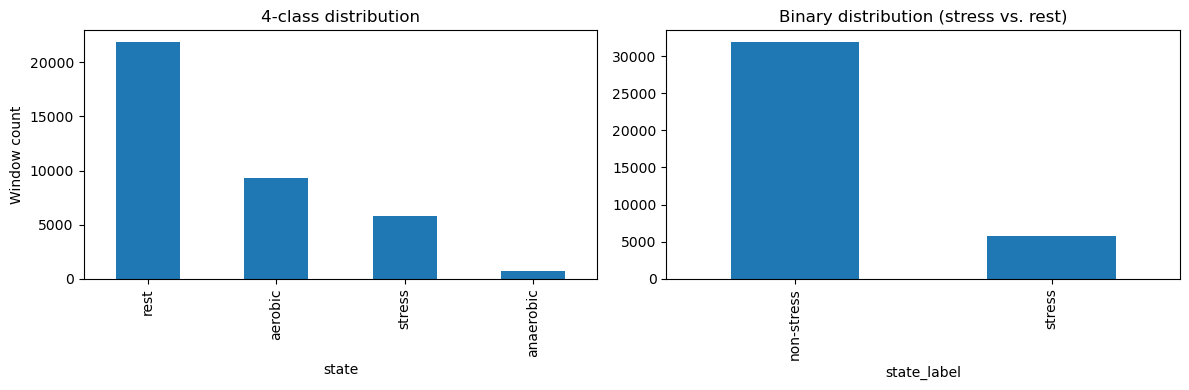

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 4-class
dataset_clean["state_label"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("4-class distribution")
axes[0].set_xlabel("state")
axes[0].set_ylabel("Window count")

# Binary
binary = dataset_clean["state_label"].map(lambda x: "stress" if x == "stress" else "non-stress")
binary.value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Binary distribution (stress vs. rest)")
plt.tight_layout()

It's important to note that in the binary split, only cognitive stress is recognised under the 'stress' label.

### _**Window type distribution, by participant:**_

This would be useful to know if we only want to use data of the people we can distinguish between all states (the participants that did all three stages).

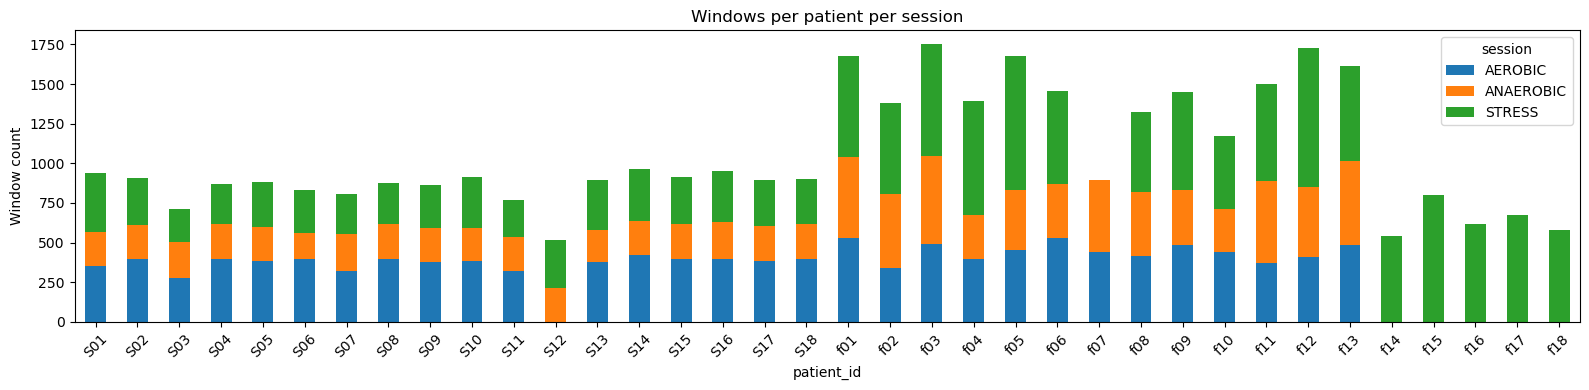

In [147]:
counts = dataset_clean.groupby(["patient_id", "session"]).size().unstack(fill_value=0)
counts.plot(kind="bar", stacked=True, figsize=(16, 4))
plt.title("Windows per patient per session")
plt.ylabel("Window count")
plt.xticks(rotation=45)
plt.tight_layout()

### _**Feature distributions by state:**_

This could prove useful for choosing features to train models with. If they have different distributions between the target variables, they could be a distinguishing factor when determining the state of a new unseen window.

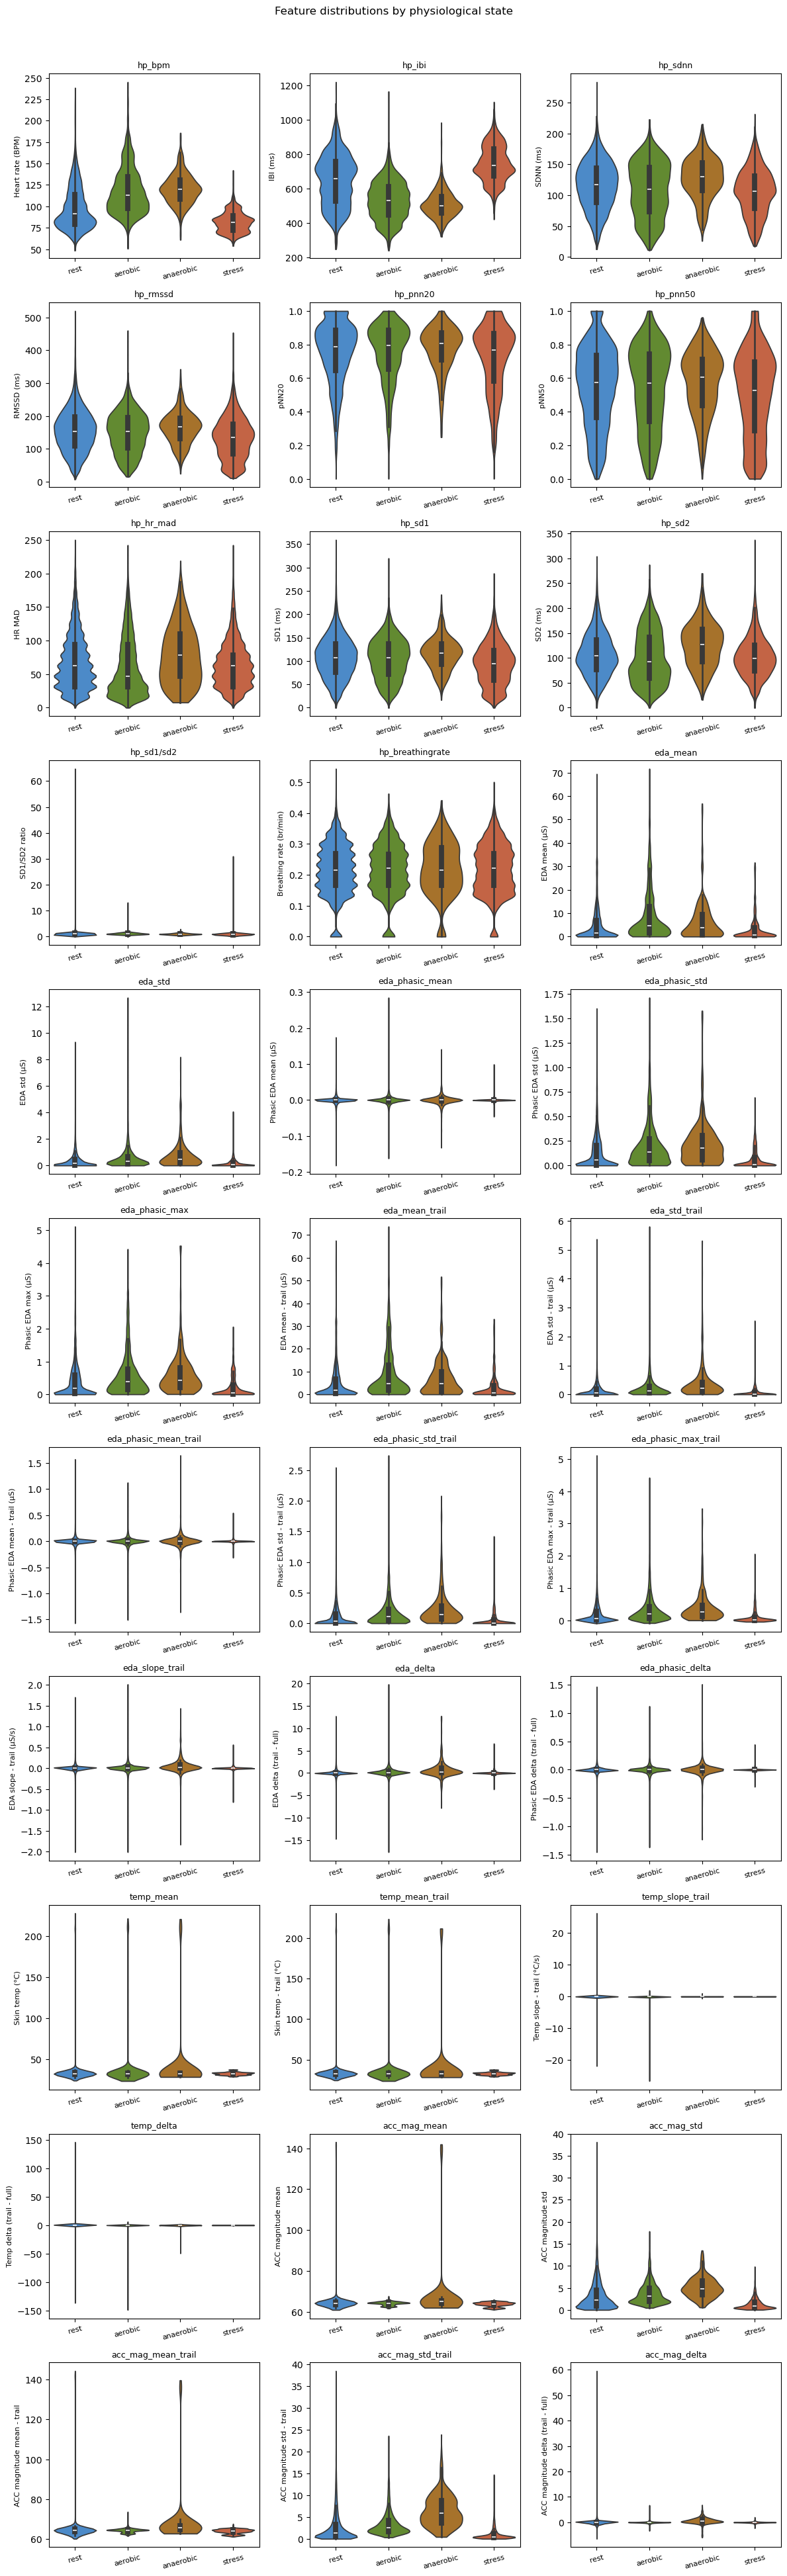

In [150]:
features = [
    # ── HeartPy (full window) ────────────────────────────────
    ("hp_bpm",           "Heart rate (BPM)"),
    ("hp_ibi",           "IBI (ms)"),
    ("hp_sdnn",          "SDNN (ms)"),
    ("hp_rmssd",         "RMSSD (ms)"),
    ("hp_pnn20",         "pNN20"),
    ("hp_pnn50",         "pNN50"),
    ("hp_hr_mad",        "HR MAD"),
    ("hp_sd1",           "SD1 (ms)"),
    ("hp_sd2",           "SD2 (ms)"),
    ("hp_sd1/sd2",       "SD1/SD2 ratio"),
    ("hp_breathingrate", "Breathing rate (br/min)"),
    # ── EDA — full window ────────────────────────────────────
    ("eda_mean",             "EDA mean (µS)"),
    ("eda_std",              "EDA std (µS)"),
    ("eda_phasic_mean",      "Phasic EDA mean (µS)"),
    ("eda_phasic_std",       "Phasic EDA std (µS)"),
    ("eda_phasic_max",       "Phasic EDA max (µS)"),
    # ── EDA — trailing 10 s ──────────────────────────────────
    ("eda_mean_trail",        "EDA mean - trail (µS)"),
    ("eda_std_trail",         "EDA std - trail (µS)"),
    ("eda_phasic_mean_trail", "Phasic EDA mean - trail (µS)"),
    ("eda_phasic_std_trail",  "Phasic EDA std - trail (µS)"),
    ("eda_phasic_max_trail",  "Phasic EDA max - trail (µS)"),
    ("eda_slope_trail",       "EDA slope - trail (µS/s)"),
    ("eda_delta",             "EDA delta (trail - full)"),
    ("eda_phasic_delta",      "Phasic EDA delta (trail - full)"),
    # ── TEMP ─────────────────────────────────────────────────
    ("temp_mean",        "Skin temp (°C)"),
    ("temp_mean_trail",  "Skin temp - trail (°C)"),
    ("temp_slope_trail", "Temp slope - trail (°C/s)"),
    ("temp_delta",       "Temp delta (trail - full)"),
    # ── ACC ──────────────────────────────────────────────────
    ("acc_mag_mean",       "ACC magnitude mean"),
    ("acc_mag_std",        "ACC magnitude std"),
    ("acc_mag_mean_trail", "ACC magnitude mean - trail"),
    ("acc_mag_std_trail",  "ACC magnitude std - trail"),
    ("acc_mag_delta",      "ACC magnitude delta (trail - full)"),
]

state_order = ["rest", "aerobic", "anaerobic", "stress"]
palette = {
    "rest":      "#378ADD",
    "aerobic":   "#639922",
    "anaerobic": "#BA7517",
    "stress":    "#D85A30",
}

n_cols = 3
n_rows = -(-len(features) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
axes_flat = axes.flatten()

for ax, (col, label) in zip(axes_flat, features):
    sns.violinplot(
        data=dataset_clean,
        x="state_label",
        y=col,
        order=state_order,
        palette=palette,
        inner="box",
        cut=0,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=8)
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis="x", labelrotation=15, labelsize=8)

for ax in axes_flat[len(features):]:
    ax.set_visible(False)

plt.suptitle("Feature distributions by physiological state", y=1.01)
plt.tight_layout()
plt.show()

**Important note:** We need to acknowlage that most metrics are taken on the full 60s window, while the class target label is chosen bu the last 60s only. This can create simmilar values of the full window variables when they have different class labels. I suppose a way to fight this is to intoduce **trasition classes** for the moments between states, so we can diffirentiate these situations.

If we choose to go down this road, I will incliude this part of the preparation in a seperate notebook or in the notebook where the model training will take place.

### _**Feature correlations:**_

This can help us decide if we should exclude some of our features, based on them carrying the same information to the model.

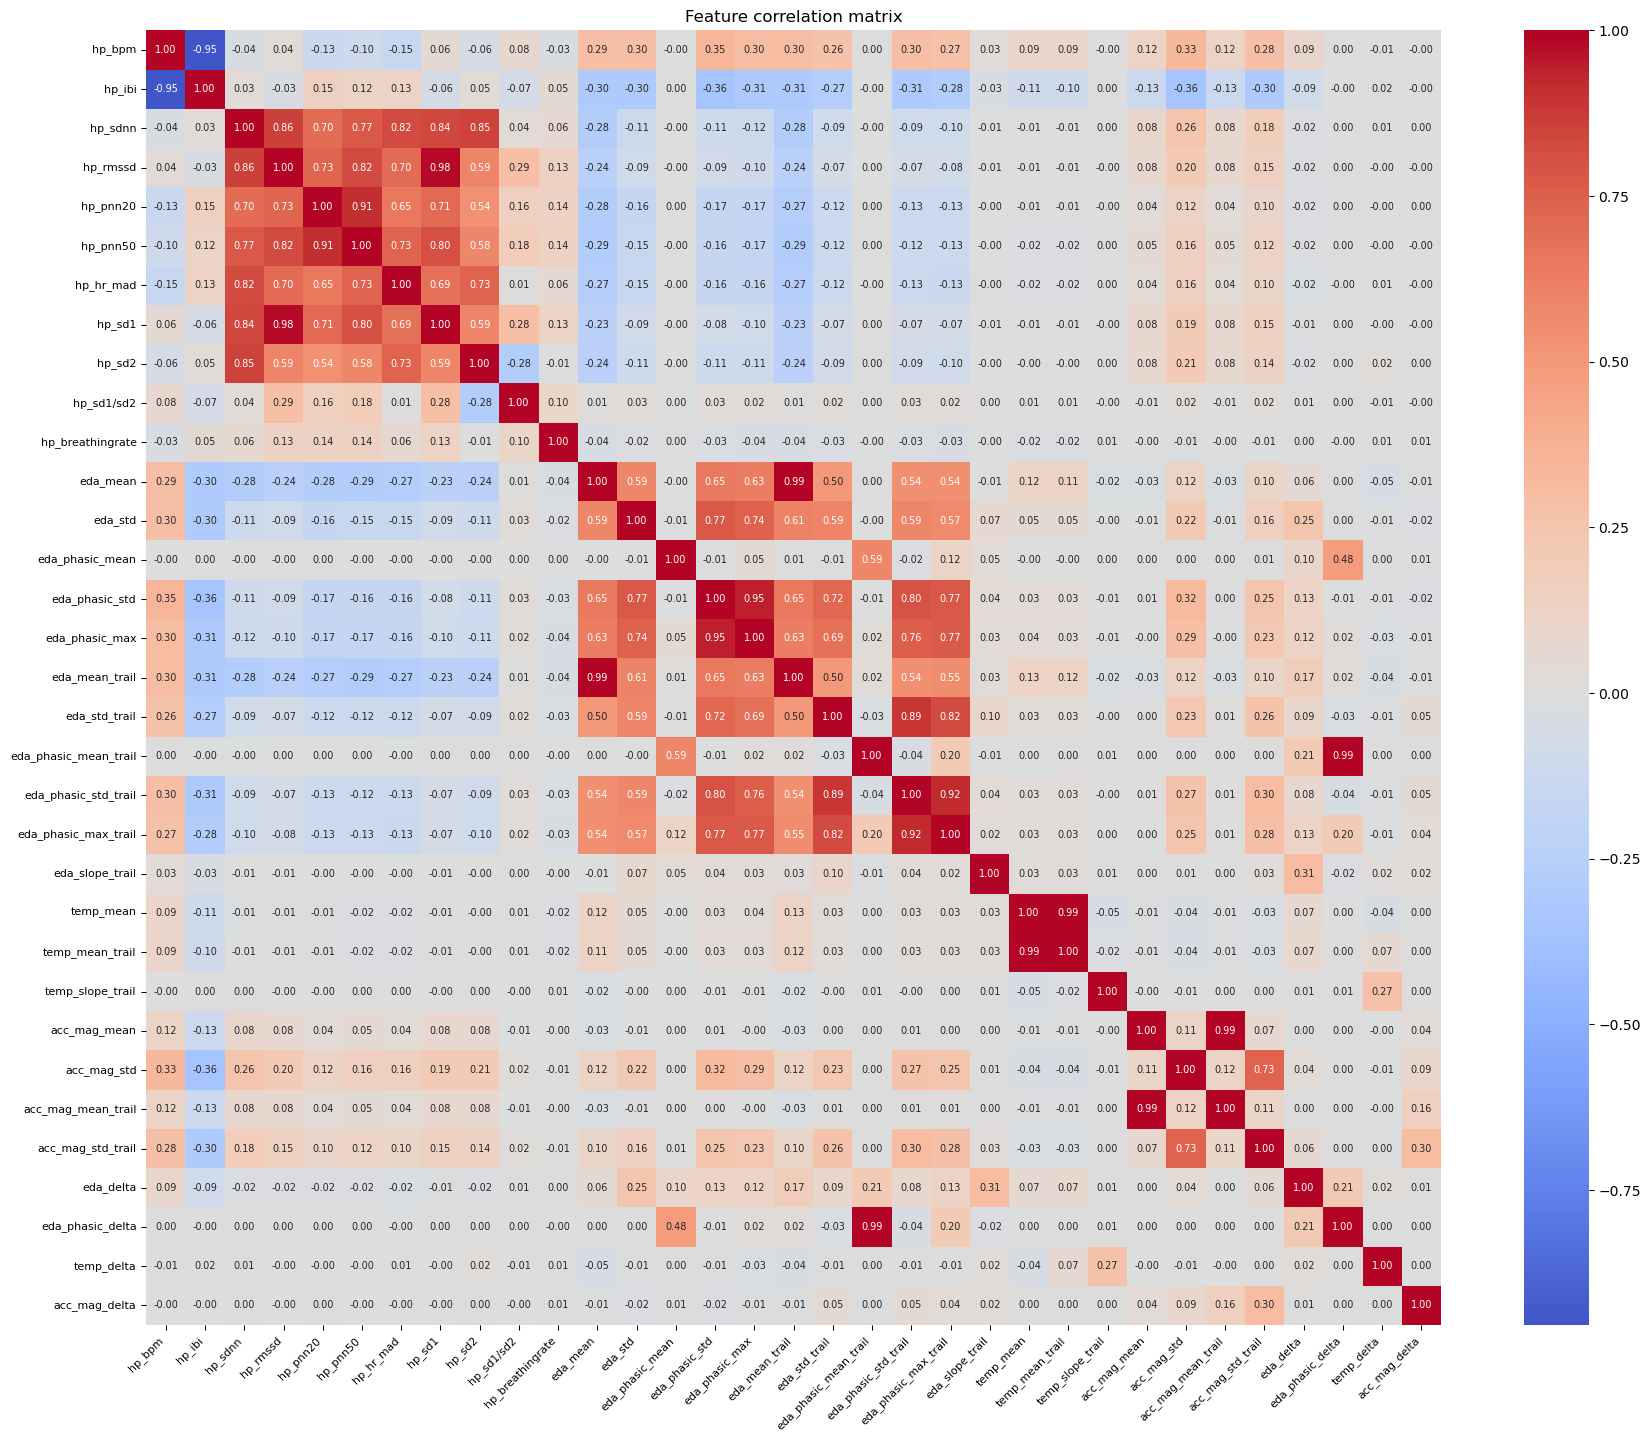

In [155]:
exclude = ["hp_quality_flag", "motion_artifact_flag", "state_label_int"]

numeric_cols = [
    c for c in dataset_clean.columns
    if (
        c.startswith("hp_")
        or c.startswith("eda_")
        or c.startswith("temp_")
        or c.startswith("acc_")
    )
    and c not in exclude
]

corr = dataset_clean[numeric_cols].corr()

n = len(numeric_cols)
fig_size = max(14, n * 0.55)
plt.figure(figsize=(fig_size, fig_size * 0.8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    annot_kws={"size": 7},
)
plt.title("Feature correlation matrix")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### _**Seing the transitions for one participant:**_

I chose some of the differing features across classes so we can see their values plotted as the experiment is done:

In [169]:
def view_temporal_reconstruction(pid="f01", sess="STRESS"):
    sub = dataset_clean[
        (dataset_clean["patient_id"] == pid) & (dataset_clean["session"] == sess)
    ].copy().sort_values("t_start_sec").reset_index(drop=True)
    
    state_colors = {
        "rest":      "lightblue",
        "stress":    "lightsalmon",
        "aerobic":   "lightgreen",
        "anaerobic": "lightyellow",
    }

    segments = []
    seg_start = sub.loc[0, "t_start_sec"]
    seg_state = sub.loc[0, "state_label"]

    for i in range(1, len(sub)):
        if sub.loc[i, "state_label"] != seg_state:
            segments.append((seg_start, sub.loc[i, "t_start_sec"], seg_state))
            seg_start = sub.loc[i, "t_start_sec"]
            seg_state = sub.loc[i, "state_label"]
    segments.append((seg_start, sub["t_end_sec"].iloc[-1], seg_state))

    phase_changes = sub[sub["phase"] != sub["phase"].shift()]["t_start_sec"].values

    features = ["hp_bpm", "hp_ibi", "eda_phasic_std", "acc_mag_std_trail"]
    colors   = ["steelblue", "coral", "green", "purple"]

    fig, axes = plt.subplots(len(features), 1, figsize=(16, 12), sharex=True)

    for ax, feat, color in zip(axes, features, colors):
        ax.plot(sub["t_start_sec"], sub[feat], color=color, linewidth=0.8)
        ax.set_ylabel(feat)

        for seg_s, seg_e, state in segments:
            ax.axvspan(seg_s, seg_e, alpha=0.25,
                       color=state_colors.get(state, "white"), zorder=0)

        for x in phase_changes:
            ax.axvline(x, color="gray", linestyle="--", linewidth=0.6, alpha=0.7)

    axes[-1].set_xlabel("Time from session start (s)")
    fig.suptitle(f"{pid} — {sess} session: signals over time")
    plt.tight_layout()
    plt.show()

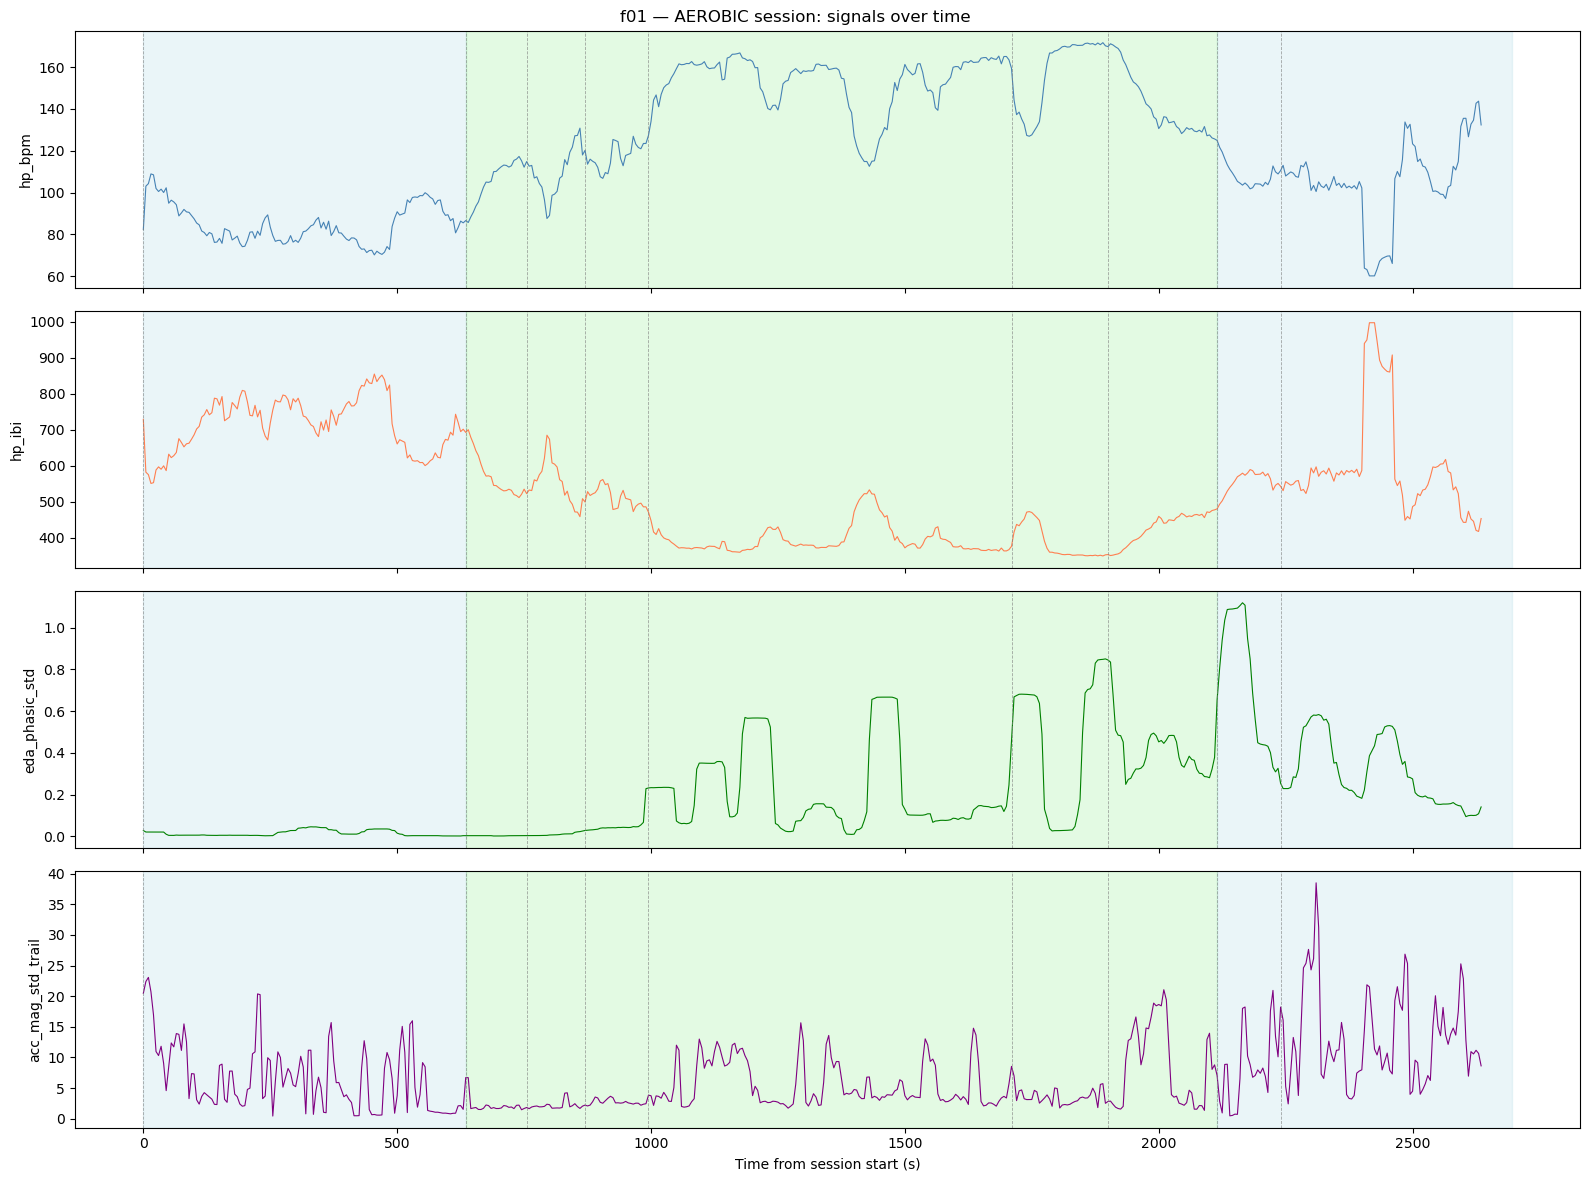

In [171]:
view_temporal_reconstruction(pid="f01", sess="AEROBIC")

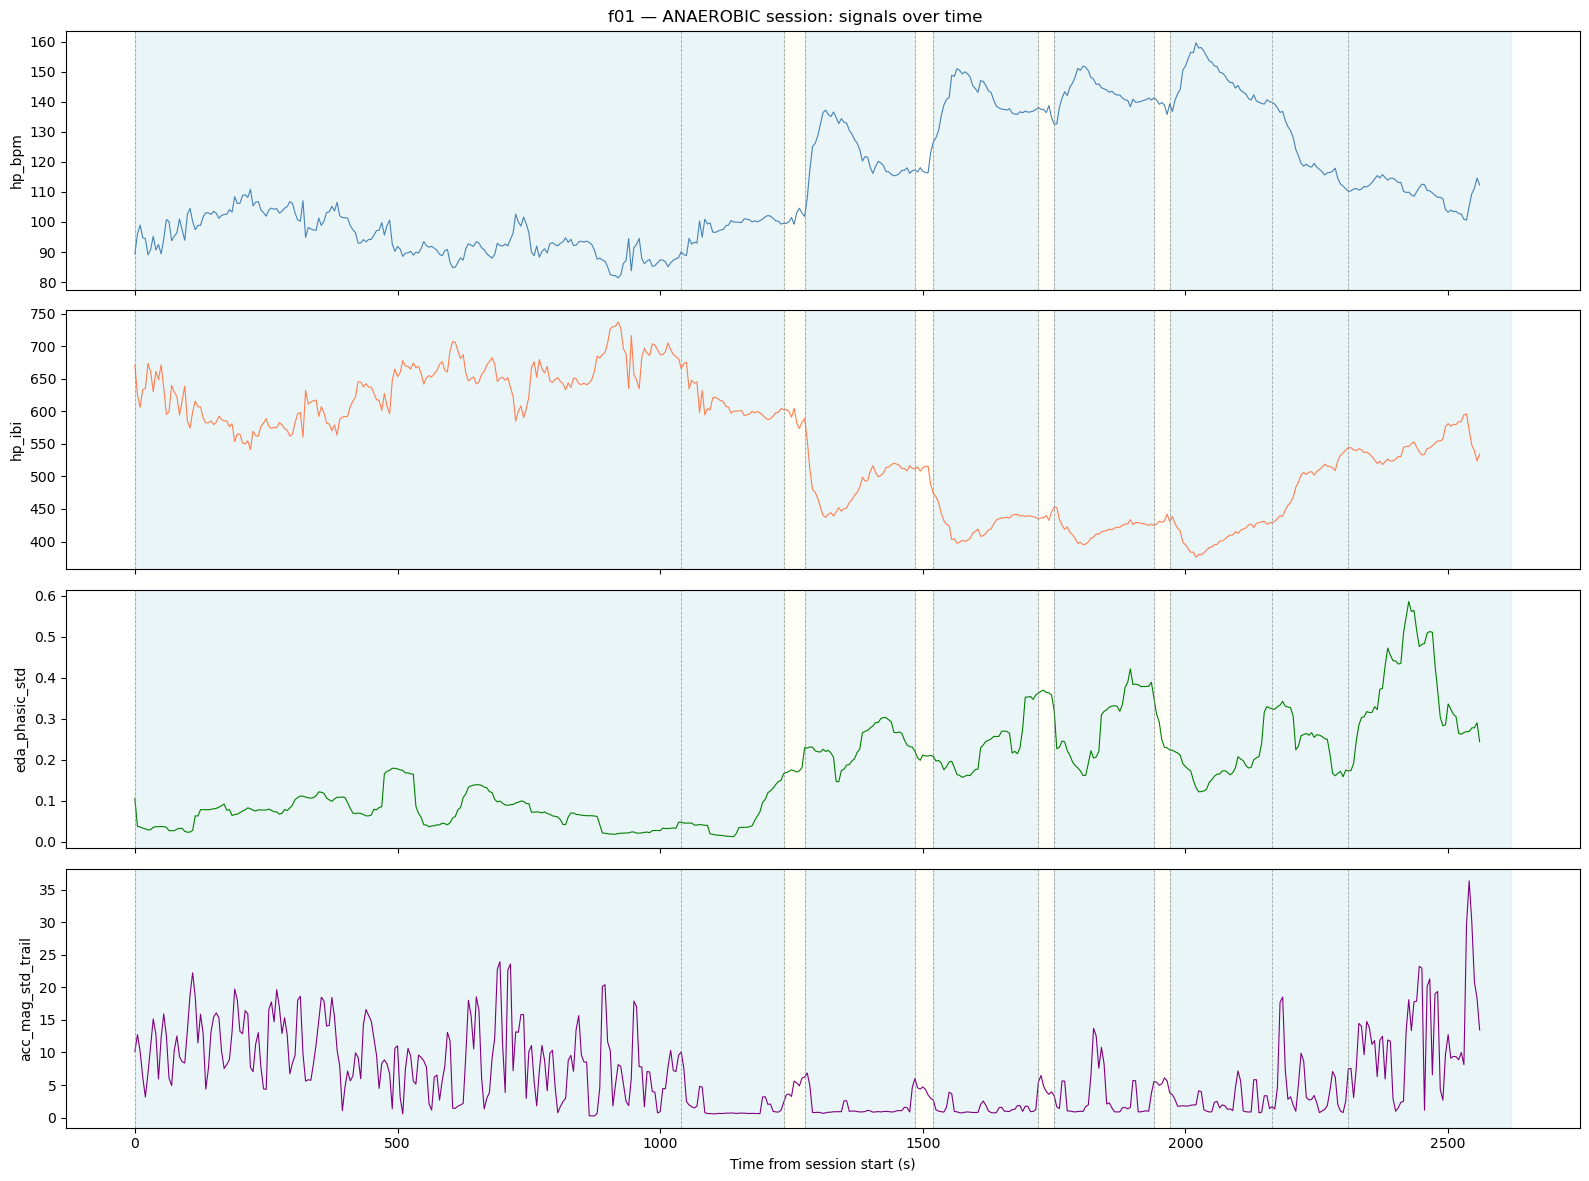

In [172]:
view_temporal_reconstruction(pid="f01", sess="ANAEROBIC")

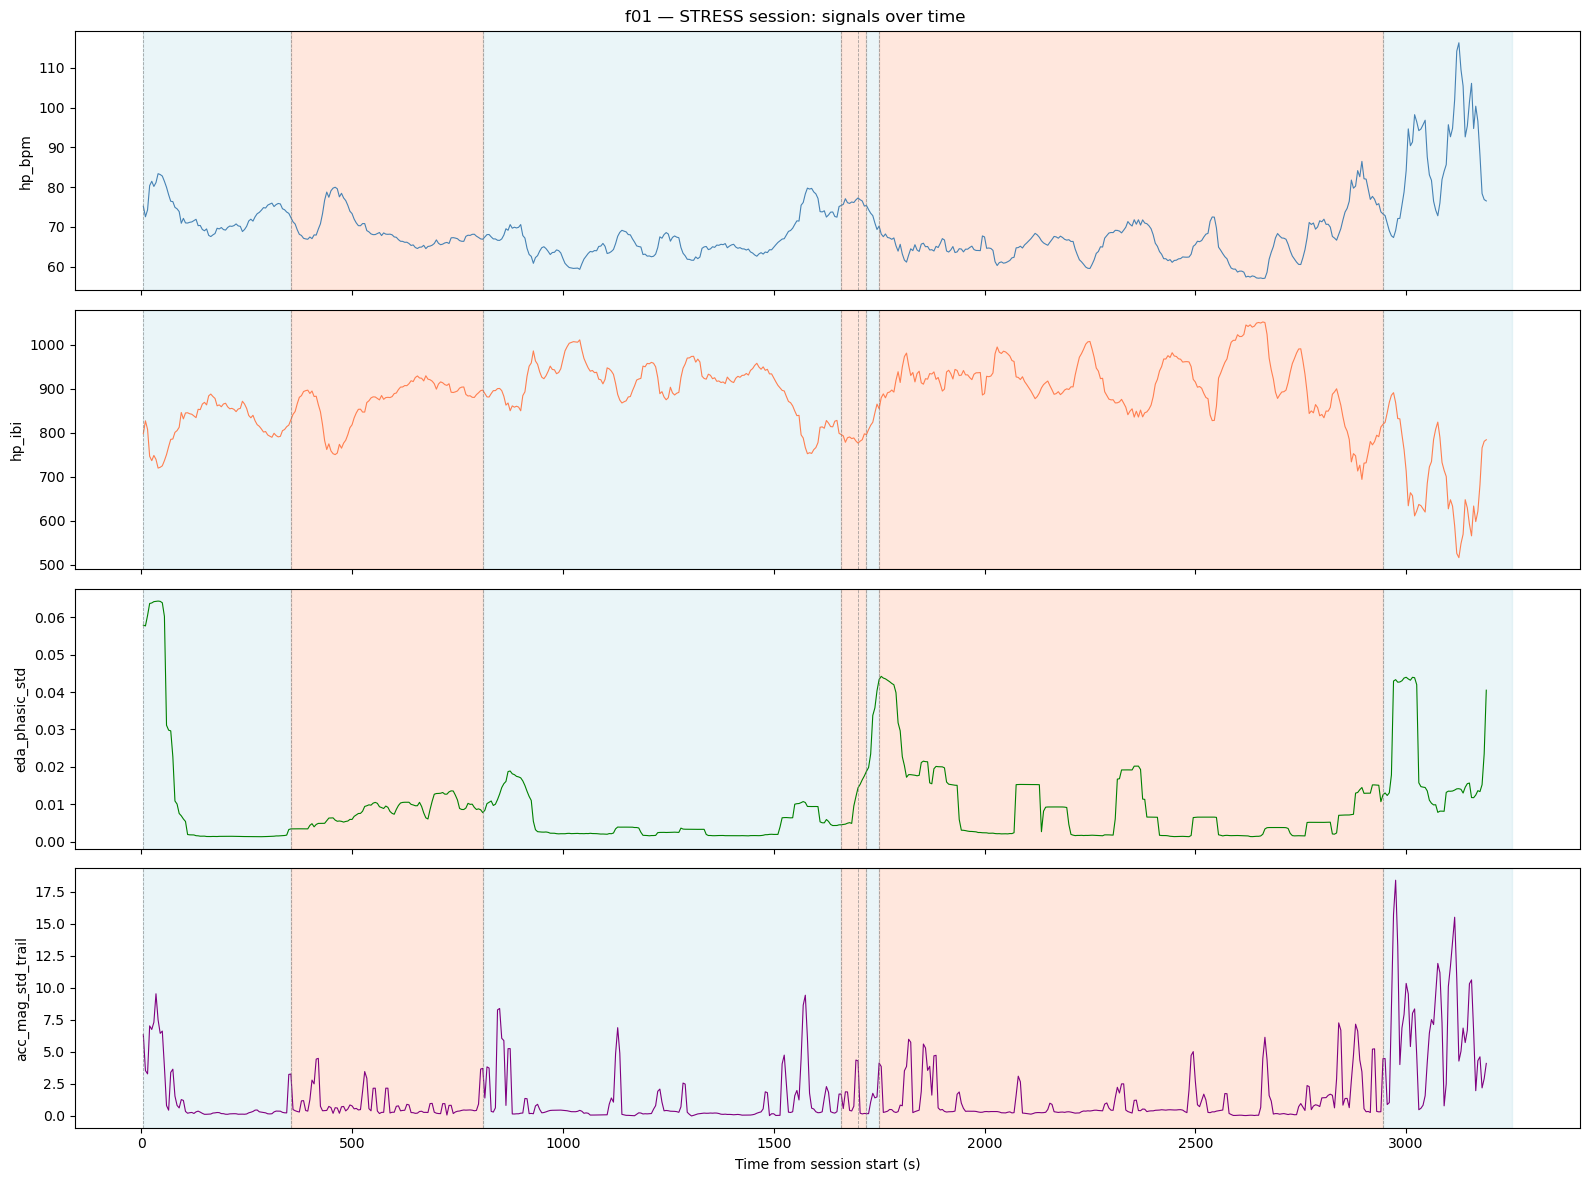

In [173]:
view_temporal_reconstruction(pid="f01", sess="STRESS")

### _**Inter-subject variability:**_

Let's take a look at the resting average BPM and EDA across all the participants:

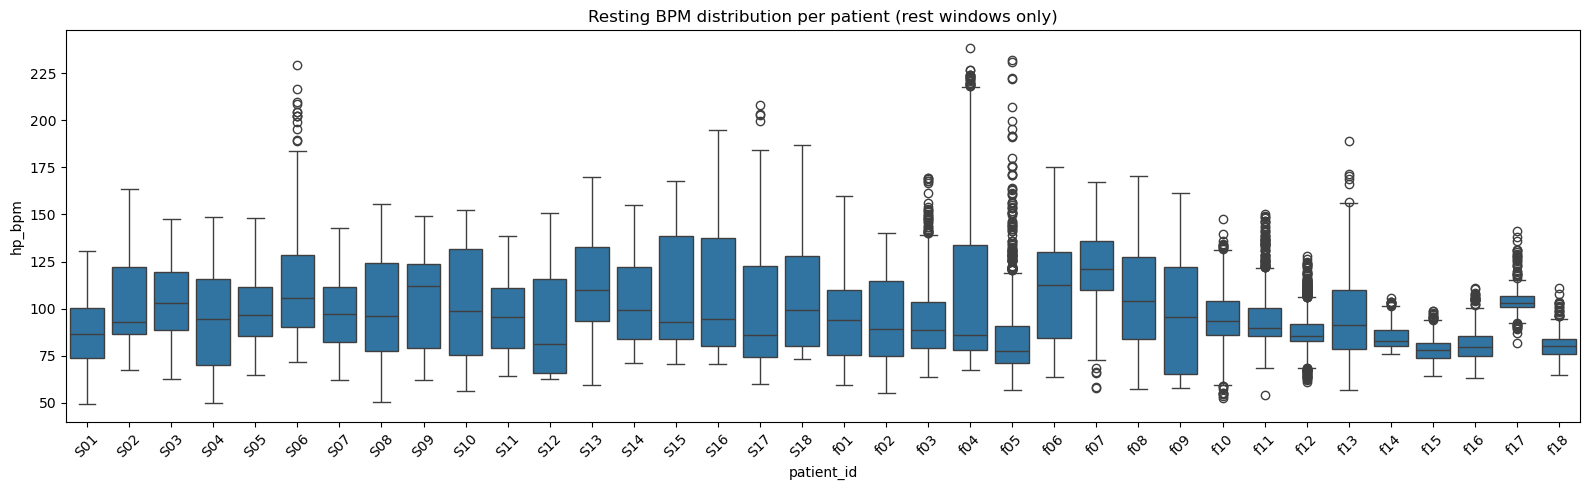

In [179]:
rest_windows = dataset_clean[dataset_clean["state_label"] == "rest"]

plt.figure(figsize=(16, 5))
sns.boxplot(data=rest_windows, x="patient_id", y="hp_bpm", order=sorted(rest_windows["patient_id"].unique()))
plt.xticks(rotation=45)
plt.title("Resting BPM distribution per patient (rest windows only)")
plt.tight_layout()

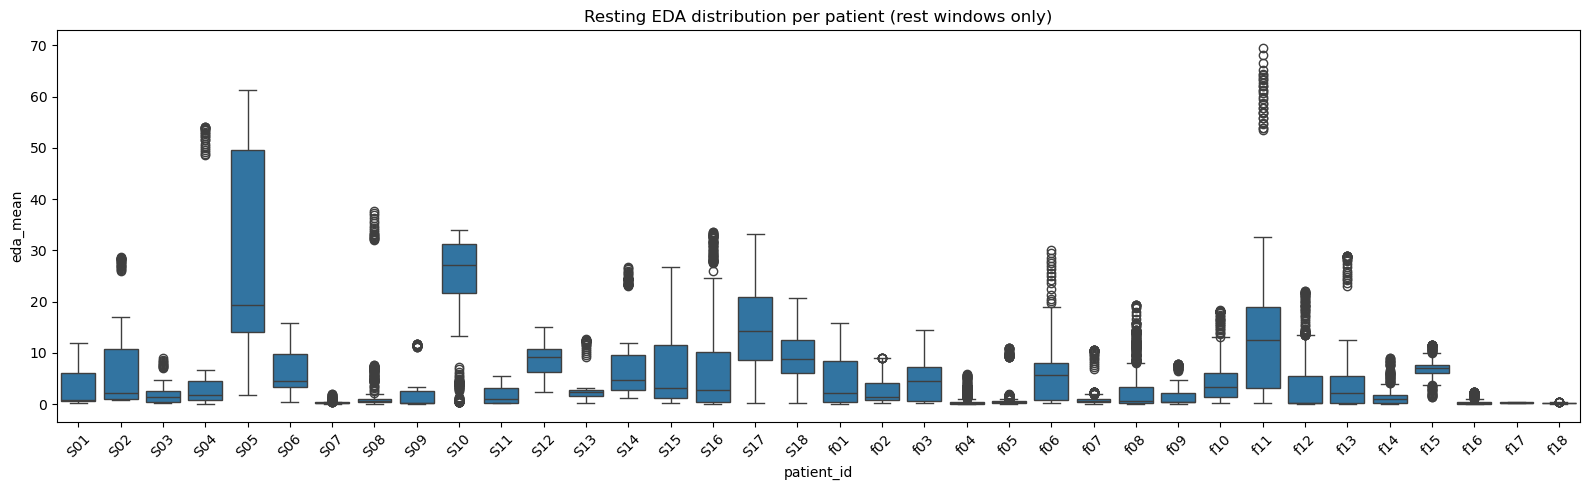

In [180]:
rest_windows = dataset_clean[dataset_clean["state_label"] == "rest"]

plt.figure(figsize=(16, 5))
sns.boxplot(data=rest_windows, x="patient_id", y="eda_mean", order=sorted(rest_windows["patient_id"].unique()))
plt.xticks(rotation=45)
plt.title("Resting EDA distribution per patient (rest windows only)")
plt.tight_layout()

We can see some variety here, this means we might need to modify our data to be **normalized per subject**.

### _**Motion artifact and HeartPy failure analysys:**_

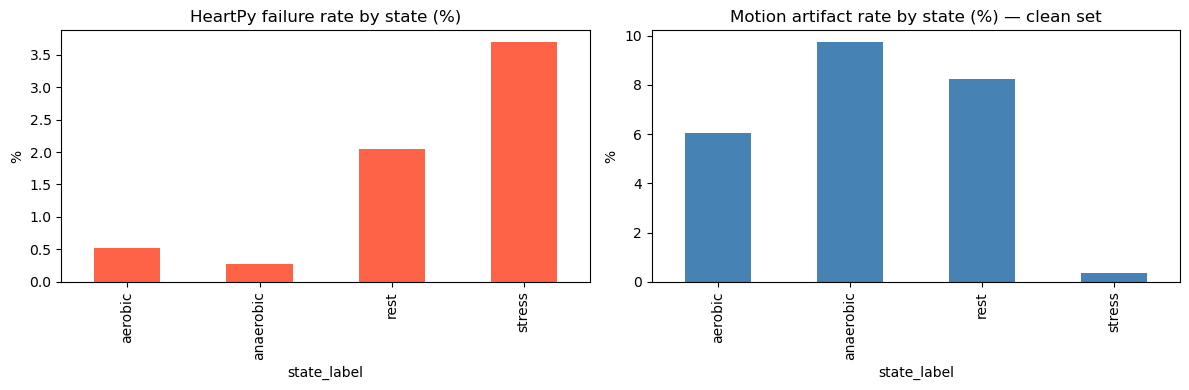

In [184]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hp_fail = dataset.groupby("state_label")["hp_quality_flag"].mean() * 100
hp_fail.plot(kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("HeartPy failure rate by state (%)")
axes[0].set_ylabel("%")

ma = dataset_clean.groupby("state_label")["motion_artifact_flag"].mean() * 100
ma.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Motion artifact rate by state (%) — clean set")
axes[1].set_ylabel("%")
plt.tight_layout()